# Đo hiệu năng trên Raspberry Pi 5

Notebook tổng hợp kết quả chạy `src/ml/run_pi_benchmark.sh` trên Raspberry Pi 5. Mọi bảng, hình
và phép kiểm tra bên dưới tính từ file commit trong `src/ml/experiments/`. Chỉ số liệu tham chiếu
của máy phát triển ở mục 10 lấy từ báo cáo trước, có ghi nguồn. Phần nhận xét dẫn lại số từ các
bảng đó.

Notebook trả lời ba câu hỏi:

1. Pipeline nhận diện có chạy kịp mốc dưới 2 giây mỗi lượt xe trên Pi 5 như đề cương cam kết
   không, và cấu hình nào nhanh nhất.
2. Trên Pi, nên dùng bản `.pt` hay `.onnx` cho bước định vị xe, và ResNet18 hay MobileNetV3-Small
   cho bước kiểu dáng xe.
3. Pi tiêu bao nhiêu điện khi xử lý một lượt xe.

**Ba lần chạy.** Chỉ `pi5/` (lần chạy chính) được dùng cho kết quả. Hai lần trước giữ lại làm bằng
chứng vì mỗi lần lộ ra một lỗi của chính cách đo:

| Thư mục | Lỗi | Hệ quả |
|---|---|---|
| `pi5_lan1_khong_cho_nguoi/` | Các loạt chạy nối liền, không chờ máy nguội | Nhiệt dồn, loạt cuối chạm giới hạn nhiệt mềm 80 °C, trượt nhiều kiểm tra ở mục 4 |
| `pi5_lan2_nhan_onnx_sai/` | `benchmark_pipeline.py` bản cũ không đọc biến `ML_COARSE_WEIGHTS` | Loạt gắn nhãn "onnx" thực chất vẫn chạy `.pt`; số thời gian vẫn đúng cho `.pt` nhưng không so được hai nhánh |
| `pi5/` | Đã sửa cả hai: chờ nguội trước mỗi loạt, script đọc biến môi trường và in tên model thật sự chạy vào đầu log | Dùng cho mọi kết quả |

Lỗi thứ hai được phát hiện khi chuẩn bị đo MobileNetV3-Small: đọc lại code thì thấy biến môi trường
không được truyền vào pipeline, và không log nào ghi model đã chạy nên không có cách phát hiện từ số
liệu. Nhờ lỗi này, mục 4 có thêm một bảng đo lặp cùng một cấu hình tới 5 lần.

| File trong mỗi thư mục | Nội dung | Sinh bởi |
|---|---|---|
| `may_do.txt` | Cấu hình phần cứng, hệ điều hành, nguồn, quạt | `run_pi_benchmark.sh` |
| `bench_<cấu hình>_<n>luong.log` | Output gốc của `benchmark_pipeline.py` | `run_pi_benchmark.sh` |
| `tai_lien_tuc_<cấu hình>_4luong.log` | Loạt 60 lượt liên tục | `run_pi_benchmark.sh` |
| `nhat_ky_dien.csv` | Công suất, nhiệt độ, quạt, tải CPU, cờ giảm xung, mỗi giây 1 mẫu | `pi_power_monitor.py` |
| `moc_thoi_gian.csv` | Mốc bắt đầu, kết thúc, nhiệt độ lúc bắt đầu từng loạt | `run_pi_benchmark.sh` |
| `tong_hop.csv`, `tung_buoc.csv`, `model_rieng.csv` | Bảng đã ghép log thời gian với log điện | `summarize_pi_benchmark.py` |
| `ram_<cấu hình>_4luong.log` | Bộ nhớ tối đa của tiến trình (chỉ lần chạy chính) | `run_pi_ram.sh` |

Chạy lại từ đầu:

```sh
# Trên Pi
bash src/ml/run_pi_benchmark.sh && bash src/ml/run_pi_ram.sh
# Trên máy dev, sau khi chép thư mục experiments/pi5 về
python src/ml/summarize_pi_benchmark.py
```

## 0. Setup

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve().parents[2] if Path.cwd().name == "notebooks" else Path.cwd()
EXP = REPO_ROOT / "src" / "ml" / "experiments"
PI5 = EXP / os.environ.get("PI5_DIR", "pi5")
PI5_LAN2 = EXP / "pi5_lan2_nhan_onnx_sai"
PI5_LAN1 = EXP / "pi5_lan1_khong_cho_nguoi"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def doc_may_do(thu_muc):
    return dict(d.split(": ", 1) for d in (thu_muc / "may_do.txt").read_text(encoding="utf-8").splitlines()
                if ": " in d)


def so_vn(x, n=1):
    """Định dạng số kiểu Việt: dấu chấm ngăn nghìn, dấu phẩy thập phân."""
    return f"{x:,.{n}f}".replace(",", "_").replace(".", ",").replace("_", ".")


tong_hop = pd.read_csv(PI5 / "tong_hop.csv")
tung_buoc = pd.read_csv(PI5 / "tung_buoc.csv")
model_rieng = pd.read_csv(PI5 / "model_rieng.csv")
dien = pd.read_csv(PI5 / "nhat_ky_dien.csv")
moc = pd.read_csv(PI5 / "moc_thoi_gian.csv")
may_do = doc_may_do(PI5)

CAU_HINH = ["pt", "onnx", "onnx_mnv3"]
TEN = {"pt": "định vị .pt, kiểu dáng ResNet18",
       "onnx": "định vị .onnx, kiểu dáng ResNet18",
       "onnx_mnv3": "định vị .onnx, kiểu dáng MobileNetV3-Small"}
# Model mà mỗi cấu hình phải chạy, dùng để đối chiếu với tên model in ở đầu log
MODEL_DUNG = {"pt": ("yolov8n.pt", "vehicle-style-resnet18.onnx"),
              "onnx": ("yolov8n.onnx", "vehicle-style-resnet18.onnx"),
              "onnx_mnv3": ("yolov8n.onnx", "vehicle-style-mobilenet_v3_small.onnx")}
# Okabe-Ito, cùng bộ màu các notebook khác trong repo (an toàn cho người mù màu)
MAU = {"pt": "#0072B2", "onnx": "#E69F00", "onnx_mnv3": "#009E73"}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})

bench = tong_hop[tong_hop.loat.str.startswith("bench_")].copy()
lien_tuc = tong_hop[tong_hop.loat.str.startswith("tai_lien_tuc")].copy()
nghi = tong_hop[tong_hop.loat.str.startswith("nghi_")].set_index("loat")
print(f"Đọc {PI5.name}: {len(dien)} mẫu điện ({len(dien) / 60:.1f} phút), "
      f"{len(bench)} loạt ngắn, {len(lien_tuc)} loạt liên tục, cấu hình: {sorted(bench.cau_hinh.unique())}")

Đọc pi5: 1452 mẫu điện (24.2 phút), 9 loạt ngắn, 3 loạt liên tục, cấu hình: ['onnx', 'onnx_mnv3', 'pt']


## 1. Máy đo

Đọc thẳng từ `may_do.txt`, do script ghi lúc bắt đầu đo.

In [2]:
header = (PI5 / "bench_pt_4luong.log").read_text(encoding="utf-8")


def _lay(nhan):
    m = re.search(rf"{nhan}\s*:\s*(.+)", header)
    return m.group(1).strip() if m else "?"


bang_may = pd.DataFrame([
    ("Thiết bị", f"{may_do['model']} (revision {may_do['revision']})"),
    ("RAM", f"{int(may_do['ram_mb']) / 1024:.0f} GB"),
    ("CPU", "Broadcom BCM2712, 4 lõi Cortex-A76, governor " + may_do["governor_cpu"]),
    ("Hệ điều hành", f"{may_do['he_dieu_hanh']}, kernel {may_do['kernel']}"),
    ("Firmware", may_do["firmware"]),
    ("Ổ đĩa gốc", may_do["o_dia_goc"] + (" (thẻ microSD)" if "mmcblk" in may_do["o_dia_goc"] else "")),
    ("Nguồn (dòng tối đa khai báo)", f"{may_do['nguon_max_ma']} mA"),
    ("Tản nhiệt", f"quạt chủ động, {may_do['quat_rpm_luc_bat_dau']} vòng/phút lúc bắt đầu"),
    ("Ngưỡng chờ nguội trước mỗi loạt", f"{may_do.get('nguong_cho_nguoi_c', '?')} °C"),
    ("Python", may_do["python"]),
    ("onnxruntime", _lay("onnxruntime")),
    ("torch", _lay("torch")),
    ("numpy / opencv", _lay("numpy/opencv")),
], columns=["Mục", "Giá trị"])
display(bang_may.style.hide(axis="index"))

Mục,Giá trị
Thiết bị,Raspberry Pi 5 Model B Rev 1.1 (revision e04171)
RAM,16 GB
CPU,"Broadcom BCM2712, 4 lõi Cortex-A76, governor ondemand"
Hệ điều hành,"Debian GNU/Linux 13 (trixie), kernel 6.18.34+rpt-rpi-2712"
Firmware,2025/05/08 15:13:17
Ổ đĩa gốc,/dev/mmcblk0p2 (thẻ microSD)
Nguồn (dòng tối đa khai báo),3000 mA
Tản nhiệt,"quạt chủ động, 3744 vòng/phút lúc bắt đầu"
Ngưỡng chờ nguội trước mỗi loạt,58 °C
Python,3.13.5


Ba điểm cấu hình cần nhớ khi đọc số. Máy chạy trên thẻ microSD, nên lượt đầu tiên (có nạp model)
chậm hơn so với chạy trên SSD. Củ sạc chỉ khai báo 3000 mA, thấp hơn 5000 mA của củ chính hãng;
mục 4 kiểm tra riêng rằng củ sạc này không gây sụt áp lúc đo. Governor CPU là `ondemand`, giống lúc
Pi chạy thật ở trạm cổng.

## 2. Cách đo thời gian suy luận

Dùng lại `src/ml/benchmark_pipeline.py`, đúng script đã đo trên máy phát triển ở báo cáo tuần 7,
để hai bên so được với nhau.

**Đồng hồ.** `time.perf_counter()` của Python, đồng hồ đơn điệu độ phân giải cao. Nó đo thời
gian đồng hồ tường, tức khoảng thời gian thật người dùng phải chờ, không phải CPU-time.

**Công thức.** Với mỗi cấu hình:

$$t_{\text{suy luận}} = \operatorname{trung\ vị}_{i=1..10}\big(\text{perf\_counter}_{\text{sau},i} - \text{perf\_counter}_{\text{trước},i}\big)$$

trong đó mỗi lượt $i$ là một lần gọi `OnnxAlprPipeline.run(ảnh)`, đúng hàm backend gọi thật.

**Làm nóng.** Bỏ 3 lượt đầu. Lượt đầu phải nạp trọng số từ thẻ nhớ và chọn kernel tính toán
nên chậm bất thường; tính vào thì trung vị bị lệch. Lượt đầu vẫn được ghi riêng ở cột
`luot_dau_ms` để biết độ trễ khi hệ thống vừa khởi động.

**Vì sao trung vị.** Trung bình bị kéo lệch bởi vài lượt tình cờ trùng lúc hệ điều hành chạy
việc nền. Script in kèm min và max để thấy độ dao động thật.

**Phạm vi.** Chỉ tính phần tính toán của pipeline. Không tính đọc ảnh từ đĩa, truyền HTTP,
ghi cơ sở dữ liệu. Ảnh đo là `docs/research/assets/dataset-samples/1_bomaich_detect.png`
(1200×600, 12 biển số), cùng ảnh đã đo trên máy phát triển. Thời gian phụ thuộc số biển trên
ảnh vì bước màu biển và OCR chạy lặp cho từng biển, nên đổi ảnh là không so được nữa.

**Chỉ số phụ: số luồng thực dùng.**

$$\text{tỉ số} = \frac{\text{CPU-time (time.process\_time)}}{\text{thời gian đồng hồ tường}}$$

Bằng khoảng 1 là chạy gần như đơn luồng. Lớn hơn số lõi thật là dấu hiệu tỏa luồng quá mức.

**Ma trận đo.** Ba mức luồng (`ML_INTRAOP_THREADS` = 1, 2, 4; Pi 5 có 4 lõi) nhân ba cấu hình
model, chọn bằng hai biến môi trường giống backend:

| Cấu hình | `ML_COARSE_WEIGHTS` (định vị xe) | `ML_STYLE_ONNX` (kiểu dáng) |
|---|---|---|
| `pt` | `yolov8n.pt` qua ultralytics | `vehicle-style-resnet18.onnx` |
| `onnx` | `yolov8n.onnx` qua onnxruntime | `vehicle-style-resnet18.onnx` |
| `onnx_mnv3` | `yolov8n.onnx` qua onnxruntime | `vehicle-style-mobilenet_v3_small.onnx` |

`benchmark_pipeline.py` in tên hai model thật sự chạy ở đầu mỗi log; mục 4 đối chiếu tên đó với
tên cấu hình.

## 3. Cách đo điện năng

**Dụng cụ.** Pi 5 có chip quản lý nguồn Renesas DA9091 (PMIC). Chip này có sẵn bộ chuyển đổi
tương tự số (ADC) đo dòng và áp của từng nhánh nguồn trên bo. Firmware cho đọc qua lệnh
`vcgencmd pmic_read_adc`. Đây là số đo bằng phần cứng, không phải ước lượng từ phần trăm
CPU. Pi 4 không có chip này, nên chỉ Pi 5 đọc được bằng phần mềm.

**Công thức.** Lệnh trả về 12 nhánh, mỗi nhánh một cặp dòng `<TÊN>_A` và áp `<TÊN>_V`:

$$P_{\text{tổng}} = \sum_{k=1}^{12} V_k \times I_k$$

Chỉ cộng nhánh có đủ cả cặp. `EXT5V_V` và `BATT_V` bị loại vì chỉ có áp, không có dòng.

**Tần suất và gán mẫu vào loạt.** `pi_power_monitor.py` lấy 1 mẫu mỗi giây, ghi kèm
`t_unix`. Script đo ghi mốc bắt đầu và kết thúc từng loạt vào `moc_thoi_gian.csv`. Công suất
của một loạt là trung vị các mẫu nằm trong mốc của loạt đó.

**Đường nền.** Pi nghỉ 60 giây trước khi đo và 60 giây sau khi đo xong:

$$P_{\text{nghỉ}} = \operatorname{trung\ vị}(\text{mẫu nghỉ đầu} \cup \text{mẫu nghỉ cuối})$$

**Chờ nguội trước mỗi loạt.** Trước từng loạt (kể cả hai lần nghỉ), script chờ SoC xuống dưới
58 °C, tối đa 5 phút, và ghi nhiệt độ lúc bắt đầu cùng số giây đã chờ vào `moc_thoi_gian.csv`.
Chọn 58 °C vì quạt mặc định của Pi 5 quay chậm lại khi SoC dưới 60 °C, lúc nghỉ SoC chỉ xuống quanh
55-56 °C; đặt ngưỡng thấp hơn thì không bao giờ tới. Mục đích là mọi loạt bắt đầu cùng một trạng
thái nhiệt.

**Điện năng một lượt xe.** Báo hai số, vì chúng trả lời hai câu hỏi khác nhau:

$$E_{\text{toàn phần}} = P_{\text{tải}} \times t_{\text{suy luận}} \qquad
E_{\text{tăng thêm}} = (P_{\text{tải}} - P_{\text{nghỉ}}) \times t_{\text{suy luận}}$$

$E_{\text{toàn phần}}$ là Pi tiêu bao nhiêu trong lúc xử lý 1 xe. $E_{\text{tăng thêm}}$ là
riêng phần do suy luận gây ra, phần còn lại Pi vẫn tiêu dù không có xe. $P_{\text{tải}}$ lấy
từ **loạt tải liên tục 60 lượt**, không lấy từ loạt ngắn: loạt ngắn có xen thời gian nạp model
và đo từng model riêng nên công suất bị pha loãng.

**Giới hạn phải nói rõ.** Số này là công suất các nhánh nguồn do PMIC cấp, **không phải công
suất đo ở ổ điện**. Không tính hao hụt của củ sạc, hao hụt khâu hạ áp từ 5 V, quạt tản nhiệt
và thiết bị cắm cổng USB, vì chúng lấy điện thẳng từ đường 5 V. Vì vậy đây là **cận dưới** của
điện năng thật. Muốn số ở ổ điện phải có đồng hồ đo USB-C rời, nhóm chưa có.

## 4. Cơ sở để tin các con số

Mỗi dòng dưới đây là một phép kiểm tra tính trên chính dữ liệu đo, không phải lời khẳng định.
Ngưỡng của 8 kiểm tra đầu được đặt trong code trước khi có dữ liệu. Kiểm tra cuối (model thật sự
chạy khớp tên cấu hình) được thêm sau khi phát hiện lỗi của lần 2; nó không có ngưỡng số, chỉ so
tên file.

Chạy cùng bộ kiểm tra trên cả ba lần chạy. Hai lần trước trượt các mục ứng với lỗi của chúng:
bằng chứng các kiểm tra này bắt được lỗi thật chứ không phải lúc nào cũng ra ✓.

Về cờ `throttled` của `vcgencmd get_throttled`: bit 0-3 là trạng thái tại lúc lấy mẫu (0 sụt áp,
1 giới hạn xung, 2 đang hạ xung, 3 chạm giới hạn nhiệt mềm), bit 16-19 là cờ dính "đã từng xảy ra
từ lúc khởi động" cùng thứ tự, chỉ xoá khi reboot. Xét một lần đo thì chỉ nhìn bit 0-3.

In [3]:
def kiem_tra_lan_chay(thu_muc):
    th = pd.read_csv(thu_muc / "tong_hop.csv")
    d = pd.read_csv(thu_muc / "nhat_ky_dien.csv")
    md_ = doc_may_do(thu_muc)
    b = th[th.loat.str.startswith("bench_")].copy()
    ng = th[th.loat.str.startswith("nghi_")].set_index("loat")
    kq = []

    # (a) Không giảm xung, không sụt áp tại lúc đo. Giảm xung làm CPU chậm lại, khi đó số thời
    # gian không còn phản ánh năng lực thật của phần cứng.
    ma = d.throttled.map(lambda s: int(s, 16))
    hien_tai = ma & 0xF
    kq.append(("Không giảm xung, không sụt áp lúc đo (bit 0-3 bằng 0 ở mọi mẫu)",
               bool((hien_tai == 0).all()), f"{int((hien_tai != 0).sum())}/{len(d)} mẫu vi phạm"))

    # (b) Riêng sụt áp: trả lời câu hỏi củ sạc có đủ không (bit 0 lúc đo, bit 16 đã từng)
    kq.append(("Củ sạc không gây sụt áp (bit 0 và bit 16 bằng 0)",
               bool(((ma & 0x10001) == 0).all()), f"nguồn khai báo {md_['nguon_max_ma']} mA"))

    # (c) Lặp lại ổn định: độ rộng min-max so với trung vị. Hẹp nghĩa là 10 lượt đo gần như
    # giống nhau, trung vị không phải con số may mắn.
    rong = (b.max_ms - b.min_ms) / b.trung_vi_ms * 100
    kq.append(("Các lượt đo lặp lại ổn định (max - min dưới 10% trung vị)",
               bool((rong < 10).all()), f"rộng nhất {rong.max():.1f}% ({b.loc[rong.idxmax(), 'loat']})"))

    # (d) Đường nền đầu và cuối buổi gần nhau. Lệch nhiều là máy đã trôi nhiệt hoặc có tiến trình
    # lạ chạy giữa chừng, hiệu số tải - nghỉ không còn đáng tin.
    p_dau, p_cuoi = ng.loc["nghi_truoc", "p_trung_vi_w"], ng.loc["nghi_sau", "p_trung_vi_w"]
    lech = abs(p_cuoi - p_dau) / p_dau * 100
    kq.append(("Đường nền không trôi (nghỉ đầu và cuối lệch dưới 10%)",
               bool(lech < 10), f"{p_dau:.2f} W so với {p_cuoi:.2f} W, lệch {lech:.1f}%"))

    # (e) Công suất đọc từ PMIC phải đi theo tải CPU. Nếu ADC chỉ trả nhiễu thì không có tương
    # quan; tương quan mạnh là bằng chứng con số phản ánh đúng việc máy đang làm.
    r = d.cpu_pct.corr(d.p_tong_w)
    kq.append(("Công suất đi theo tải CPU (tương quan Pearson trên 0,8)",
               bool(r > 0.8), f"r = {r:.3f} trên {len(d)} mẫu"))

    # (f) Nhiệt độ tối đa dưới ngưỡng Pi 5 bắt đầu hạ xung mềm
    kq.append(("Nhiệt độ tối đa dưới 80 °C", bool(d.nhiet_do_c.max() < 80), f"tối đa {d.nhiet_do_c.max():.1f} °C"))

    # (g) Tỉ số CPU/wall không vượt số lõi: không tỏa luồng quá mức làm méo số đo
    kq.append(("Không tỏa luồng quá mức (CPU-time / wall không vượt 4)",
               bool((b.ti_so_cpu_wall <= 4.0).all()), f"cao nhất {b.ti_so_cpu_wall.max():.2f}"))

    # (h) Mọi loạt bắt đầu cùng trạng thái nhiệt. Lần 1 không ghi nhiệt độ lúc bắt đầu.
    if "nhiet_do_bat_dau_c" in th and th.nhiet_do_bat_dau_c.notna().any():
        bd = th.nhiet_do_bat_dau_c.dropna()
        kq.append(("Mọi loạt bắt đầu cùng trạng thái nhiệt (chênh dưới 5 °C)",
                   bool(bd.max() - bd.min() < 5), f"{bd.min():.0f} đến {bd.max():.0f} °C"))
    else:
        kq.append(("Mọi loạt bắt đầu cùng trạng thái nhiệt (chênh dưới 5 °C)", False, "không ghi, không chờ nguội"))

    # (i) Model thật sự chạy khớp tên cấu hình, đọc từ dòng in ở đầu mỗi log
    tat_ca = th[th.loat.str.startswith(("bench_", "tai_lien_tuc_"))]
    if tat_ca.dinh_vi_file.notna().all():
        sai = [r.loat for r in tat_ca.itertuples()
               if (r.dinh_vi_file, r.kieu_dang_file) != MODEL_DUNG.get(r.cau_hinh)]
        kq.append(("Model thật sự chạy khớp tên cấu hình (đầu log)", not sai,
                   f"{len(tat_ca) - len(sai)}/{len(tat_ca)} loạt khớp"))
    else:
        kq.append(("Model thật sự chạy khớp tên cấu hình (đầu log)", False, "log không ghi model đã chạy"))
    return kq


def _o(dat, chi_tiet):
    return f"{'✓' if dat else '✗'}  {chi_tiet}"


chinh, lan2, lan1 = (kiem_tra_lan_chay(x) for x in (PI5, PI5_LAN2, PI5_LAN1))
bang_kt = pd.DataFrame({
    "Kiểm tra": [k[0] for k in chinh],
    "Lần chạy chính": [_o(k[1], k[2]) for k in chinh],
    "Lần 2 (nhãn onnx sai)": [_o(k[1], k[2]) for k in lan2],
    "Lần 1 (không chờ nguội)": [_o(k[1], k[2]) for k in lan1],
})
display(bang_kt.style.hide(axis="index").set_properties(**{"text-align": "left"}))
display(Markdown(f"Lần chạy chính đạt **{sum(k[1] for k in chinh)}/{len(chinh)}** kiểm tra; "
                 f"lần 2 đạt {sum(k[1] for k in lan2)}/{len(lan2)}; lần 1 đạt {sum(k[1] for k in lan1)}/{len(lan1)}."))

Kiểm tra,Lần chạy chính,Lần 2 (nhãn onnx sai),Lần 1 (không chờ nguội)
"Không giảm xung, không sụt áp lúc đo (bit 0-3 bằng 0 ở mọi mẫu)",✓ 0/1452 mẫu vi phạm,✓ 0/881 mẫu vi phạm,✗ 1/546 mẫu vi phạm
Củ sạc không gây sụt áp (bit 0 và bit 16 bằng 0),✓ nguồn khai báo 3000 mA,✓ nguồn khai báo 3000 mA,✓ nguồn khai báo 3000 mA
Các lượt đo lặp lại ổn định (max - min dưới 10% trung vị),✗ rộng nhất 12.1% (bench_onnx_mnv3_4luong),✗ rộng nhất 12.6% (bench_onnx_4luong),✗ rộng nhất 12.0% (bench_onnx_4luong)
Đường nền không trôi (nghỉ đầu và cuối lệch dưới 10%),"✗ 1.46 W so với 1.61 W, lệch 10.1%","✓ 1.42 W so với 1.52 W, lệch 7.5%","✗ 1.44 W so với 1.72 W, lệch 19.6%"
"Công suất đi theo tải CPU (tương quan Pearson trên 0,8)",✓ r = 0.944 trên 1452 mẫu,✓ r = 0.921 trên 881 mẫu,✓ r = 0.891 trên 546 mẫu
Nhiệt độ tối đa dưới 80 °C,✗ tối đa 81.5 °C,✓ tối đa 79.3 °C,✗ tối đa 81.5 °C
Không tỏa luồng quá mức (CPU-time / wall không vượt 4),✓ cao nhất 4.00,✓ cao nhất 3.70,✓ cao nhất 3.70
Mọi loạt bắt đầu cùng trạng thái nhiệt (chênh dưới 5 °C),✗ 53 đến 59 °C,✓ 54 đến 58 °C,"✗ không ghi, không chờ nguội"
Model thật sự chạy khớp tên cấu hình (đầu log),✓ 12/12 loạt khớp,✗ log không ghi model đã chạy,✗ log không ghi model đã chạy


Lần chạy chính đạt **5/9** kiểm tra; lần 2 đạt 7/9; lần 1 đạt 3/9.

**Đo lặp cùng một cấu hình.** Vì lỗi của lần 2 (và lần 1, cùng bản script cũ), loạt gắn nhãn "onnx"
ở hai lần đó thực chất chạy đúng cấu hình `pt`. Cộng với lần chạy chính, cấu hình định vị `.pt` +
kiểu dáng ResNet18 được đo 5 lần độc lập. Bảng này chỉ mô tả, không đặt ngưỡng, vì được lập sau khi
đã xem dữ liệu.

In [4]:
def tv(thu_muc):
    return pd.read_csv(thu_muc / "tong_hop.csv").set_index("loat").trung_vi_ms


c, l2, l1 = tv(PI5), tv(PI5_LAN2), tv(PI5_LAN1)
hang = []
for ten_pt, ten_onnx in [(f"bench_pt_{n}luong", f"bench_onnx_{n}luong") for n in (1, 2, 4)] + \
        [("tai_lien_tuc_pt_4luong", "tai_lien_tuc_onnx_4luong")]:
    so = [c[ten_pt], l2[ten_pt], l2[ten_onnx], l1[ten_pt], l1[ten_onnx]]
    tb_ = np.mean(so)
    hang.append([ten_pt, *so, max(abs(x - tb_) for x in so) / tb_ * 100])
tai_lap = pd.DataFrame(hang, columns=["Loạt (pt + ResNet18)", "Lần chính", "Lần 2, nhãn pt", "Lần 2, nhãn onnx",
                                      "Lần 1, nhãn pt", "Lần 1, nhãn onnx", "Lệch tối đa so với trung bình"])
display(tai_lap.style.hide(axis="index").format(
    {k: "{:.1f}" for k in tai_lap.columns[1:6]} | {"Lệch tối đa so với trung bình": "{:.2f}%"}))
display(Markdown(f"Trên 5 lần đo, trung vị lệch khỏi trung bình tối đa **{so_vn(tai_lap.iloc[:, -1].max(), 2)}%**."))

Loạt (pt + ResNet18),Lần chính,"Lần 2, nhãn pt","Lần 2, nhãn onnx","Lần 1, nhãn pt","Lần 1, nhãn onnx",Lệch tối đa so với trung bình
bench_pt_1luong,813.9,810.8,815.8,808.9,810.9,0.46%
bench_pt_2luong,526.3,526.8,536.5,532.6,532.7,1.04%
bench_pt_4luong,495.3,490.4,495.6,489.7,495.7,0.74%
tai_lien_tuc_pt_4luong,495.5,495.0,492.5,491.4,496.9,0.58%


Trên 5 lần đo, trung vị lệch khỏi trung bình tối đa **1,04%**.

Lần chạy chính đạt 5/9 kiểm tra. Bốn mục không đạt, nhóm giữ nguyên ngưỡng và ghi lại thay vì nới:

- Nhiệt độ lên 81,5 °C ở loạt chạy liên tục. Bit 0-3 của `throttled` vẫn bằng 0 ở cả 1.452 mẫu, tức
  Pi chưa hạ xung, nên số thời gian vẫn dùng được; nhưng máy đã ở sát giới hạn.
- Đường nền cuối buổi cao hơn đầu buổi 10,1% (ngưỡng 10%), do buổi đo 3 cấu hình dài hơn và máy nóng
  hơn; lần nghỉ cuối phải chờ nguội 230 giây. Số điện năng tăng thêm vì vậy có sai số khoảng 0,15 W.
- Nhiệt độ lúc bắt đầu các loạt chênh 6 °C (53 đến 59 °C), vượt ngưỡng 5 °C một độ.
- Một loạt (`onnx_mnv3`, 4 luồng) có 10 lượt dao động 12,1%. Với 4 luồng trên đúng 4 lõi, pipeline
  tranh CPU với hệ điều hành và bộ đo điện nên thỉnh thoảng có một lượt chậm; trung vị ít bị ảnh hưởng.

Hai mục quan trọng nhất cho kết luận đều đạt: 12/12 loạt chạy đúng model ghi trong tên cấu hình, và
cấu hình `pt` đo độc lập 5 lần cho trung vị lệch nhau không quá 1,04%.

## 5. Từng model chạy riêng

Đầu vào là tensor ngẫu nhiên đúng kích thước, chỉ đo chi phí tính toán của đồ thị ONNX. Không
cộng các dòng lại thành thời gian pipeline: chạy riêng thì mỗi model dùng trọn số luồng, còn
trong pipeline chúng chạy nối tiếp và có thêm tiền xử lý.

In [5]:
mr = model_rieng[model_rieng.loat.str.startswith("bench_pt_")]
bang_mr = mr.pivot_table(index=["model", "mb"], columns="luong", values="trung_vi_ms").reset_index()
bang_mr.columns = ["Model", "MB"] + [f"{c} luồng (ms)" for c in bang_mr.columns[2:]]
bang_mr["Tăng tốc 1 lên 4 luồng"] = bang_mr["1 luồng (ms)"] / bang_mr["4 luồng (ms)"]
display(bang_mr.sort_values("1 luồng (ms)", ascending=False).style.hide(axis="index")
        .format({"MB": "{:.1f}", "1 luồng (ms)": "{:.2f}", "2 luồng (ms)": "{:.2f}",
                 "4 luồng (ms)": "{:.2f}", "Tăng tốc 1 lên 4 luồng": "{:.2f}×"}))

Model,MB,1 luồng (ms),2 luồng (ms),4 luồng (ms),Tăng tốc 1 lên 4 luồng
Phát hiện biển (YOLOv8n),12.2,361.10,194.17,141.85,2.55×
Loại xe (ResNet18),44.7,129.47,69.05,44.99,2.88×
Kiểu dáng xe (ResNet18),44.7,129.42,69.35,45.53,2.84×
Loại xe (MobileNetV3-Small),6.1,12.66,7.58,5.75,2.20×
Kiểu dáng xe (MobileNetV3-Small),6.1,12.61,7.47,5.67,2.22×
OCR biển số (CRNN),1.7,6.07,3.41,2.30,2.64×


MobileNetV3-Small nhanh hơn ResNet18 khoảng 10 lần ở 1 luồng (12,6 ms so với 129,4 ms với model
kiểu dáng) và 8 lần ở 4 luồng (5,7 ms so với 45,5 ms). Bản ONNX của MobileNetV3-Small cho bước kiểu
dáng khớp bản `.pt` trên 987/987 ảnh test, accuracy 0,9007 ở cả hai (`experiments/style_mobilenet_onnx_parity.json`).
Model phát hiện biển số (YOLOv8n, đầu vào 640×640) vẫn nặng nhất: 361 ms ở 1 luồng.

## 6. Từng bước trong pipeline

Cùng ảnh, cùng tiến trình, đo lần lượt từng bước bên trong `OnnxAlprPipeline`. Đây là bảng chỉ
ra nút thắt thật.

,"pt, 1 luồng","pt, 2 luồng","pt, 4 luồng","onnx, 1 luồng","onnx, 2 luồng","onnx, 4 luồng","onnx_mnv3, 1 luồng","onnx_mnv3, 2 luồng","onnx_mnv3, 4 luồng"
buoc,,,,,,,,,
Phát hiện biển số (ONNX),366.1,200.0,168.0,364.5,198.8,168.3,367.9,201.1,172.4
Định vị + cắt vùng xe (YOLO),136.1,137.8,156.5,397.6,223.0,188.3,400.4,224.3,192.3
Màu biển + OCR (12 biển),165.2,103.5,109.4,164.0,102.8,104.0,164.1,104.6,104.3
Phân loại kiểu dáng (ONNX),133.0,72.9,79.4,132.3,73.0,76.3,16.0,11.1,29.3
Phân loại loại xe (ONNX),129.9,69.6,45.6,129.4,69.8,51.1,129.7,69.9,50.8
Tiền xử lý ảnh cho classifier,6.6,6.6,6.6,6.7,6.6,15.9,6.7,6.7,14.9
Chuyển màu BGR sang RGB,1.6,1.6,1.5,1.8,1.7,1.6,1.8,1.8,1.8


,"Tỉ lệ ở 4 luồng, pt","Tỉ lệ ở 4 luồng, onnx","Tỉ lệ ở 4 luồng, onnx_mnv3"
buoc,,,
Phát hiện biển số (ONNX),29.6%,27.8%,30.5%
Định vị + cắt vùng xe (YOLO),27.6%,31.1%,34.0%
Màu biển + OCR (12 biển),19.3%,17.2%,18.4%
Phân loại kiểu dáng (ONNX),14.0%,12.6%,5.2%
Phân loại loại xe (ONNX),8.0%,8.4%,9.0%
Tiền xử lý ảnh cho classifier,1.2%,2.6%,2.6%
Chuyển màu BGR sang RGB,0.3%,0.3%,0.3%


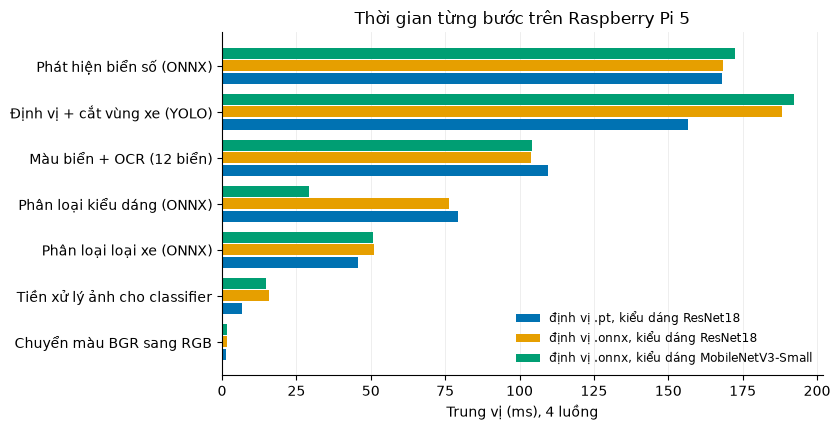

In [6]:
tb = tung_buoc[tung_buoc.loat.str.startswith("bench_")]
bang_tb = tb.pivot_table(index="buoc", columns=["cau_hinh", "luong"], values="trung_vi_ms")
bang_tb = bang_tb[[c_ for c_ in CAU_HINH if c_ in bang_tb.columns.get_level_values(0)]]
bang_tb = bang_tb.sort_values(("pt", 4), ascending=False)
bang_tb.columns = [f"{c_}, {l} luồng" for c_, l in bang_tb.columns]
display(bang_tb.style.format("{:.1f}"))

ti_le = tb[tb.luong == 4].pivot_table(index="buoc", columns="cau_hinh", values="ti_le_pct")[CAU_HINH]
ti_le = ti_le.sort_values("pt", ascending=False)
ti_le.columns = [f"Tỉ lệ ở 4 luồng, {c_}" for c_ in ti_le.columns]
display(ti_le.style.format("{:.1f}%"))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
b4 = tb[tb.luong == 4].pivot_table(index="buoc", columns="cau_hinh", values="trung_vi_ms")[CAU_HINH].sort_values("pt")
y = np.arange(len(b4))
h = 0.27
for i, c_ in enumerate(CAU_HINH):
    ax.barh(y + (i - 1) * h, b4[c_], height=h - 0.03, color=MAU[c_], label=TEN[c_])
ax.set_yticks(y, b4.index)
ax.set_xlabel("Trung vị (ms), 4 luồng")
ax.set_title("Thời gian từng bước trên Raspberry Pi 5")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "pi5_tung_buoc.png", dpi=150, bbox_inches="tight")
plt.show()

Đổi model kiểu dáng sang MobileNetV3-Small làm bước này giảm từ 132,3 ms xuống 16,0 ms ở 1 luồng,
và từ 75,8 ms xuống 27,8 ms ở 4 luồng. Bước định vị xe bằng `.onnx` chậm hơn `.pt` rõ rệt: 190 ms so
với 157 ms ở 4 luồng (ở 1 luồng là 398 ms so với 136 ms, xem log). Bản ONNX xuất tĩnh luôn xử lý
đủ khung 640×640, còn ultralytics tự co ảnh theo tỉ lệ.

Tổng các bước lớn hơn thời gian toàn pipeline, vì bảng này đo lại từng hàm tách rời và luôn chạy
bước kiểu dáng, còn `run()` chỉ chạy bước kiểu dáng khi loại xe là ô tô. Chỉ dùng bảng này để so
từng bước.

## 7. Toàn pipeline: 9 cấu hình

Cấu hình,Luồng,Lượt đầu (ms),Trung vị (ms),Min,Max,CPU-time (ms),CPU/wall,Nhiệt độ đầu (°C),Nhiệt độ max (°C),throttled bit 0-3
"định vị .pt, kiểu dáng ResNet18",1.0,962.0,813.9,811.8,823.2,1124.1,1.4,53,61.1,0x0
"định vị .pt, kiểu dáng ResNet18",2.0,668.0,526.3,524.9,534.5,1279.8,2.4,56,66.1,0x0
"định vị .pt, kiểu dáng ResNet18",4.0,604.4,495.3,487.2,535.8,1830.0,3.7,58,70.5,0x0
"định vị .onnx, kiểu dáng ResNet18",1.0,1135.3,1067.4,1066.3,1076.0,1103.7,1.0,58,64.5,0x0
"định vị .onnx, kiểu dáng ResNet18",2.0,677.1,611.6,608.5,625.9,1342.5,2.2,58,69.4,0x0
"định vị .onnx, kiểu dáng ResNet18",4.0,588.6,535.0,525.4,558.5,2129.7,4.0,58,74.9,0x0
"định vị .onnx, kiểu dáng MobileNetV3-Small",1.0,1144.1,1082.4,1076.4,1093.7,1119.1,1.0,58,65.0,0x0
"định vị .onnx, kiểu dáng MobileNetV3-Small",2.0,676.2,610.9,609.3,619.3,1340.9,2.2,58,70.0,0x0
"định vị .onnx, kiểu dáng MobileNetV3-Small",4.0,579.2,550.4,528.1,594.9,2164.2,3.9,58,74.3,0x0


Nhanh nhất: **định vị .pt, kiểu dáng ResNet18, 4 luồng, 495,3 ms mỗi lượt**, nhanh hơn mốc 2 giây của đề cương 4,0 lần.

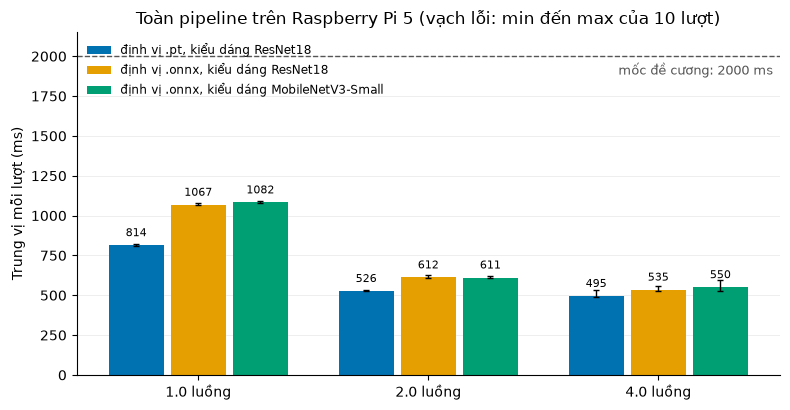

In [7]:
cot_e2e = ["cau_hinh", "luong", "luot_dau_ms", "trung_vi_ms", "min_ms", "max_ms",
           "cpu_time_ms", "ti_so_cpu_wall", "nhiet_do_bat_dau_c", "nhiet_do_max_c", "throttled_hien_tai"]
bang_e2e = bench[cot_e2e].copy()
bang_e2e["_thu_tu"] = bang_e2e.cau_hinh.map(CAU_HINH.index)
bang_e2e = bang_e2e.sort_values(["_thu_tu", "luong"]).drop(columns="_thu_tu")
bang_e2e["cau_hinh"] = bang_e2e.cau_hinh.map(TEN)
bang_e2e.columns = ["Cấu hình", "Luồng", "Lượt đầu (ms)", "Trung vị (ms)", "Min", "Max",
                    "CPU-time (ms)", "CPU/wall", "Nhiệt độ đầu (°C)", "Nhiệt độ max (°C)", "throttled bit 0-3"]
display(bang_e2e.style.hide(axis="index").format(precision=1))

tot_nhat = bench.loc[bench.trung_vi_ms.idxmin()]
display(Markdown(f"Nhanh nhất: **{TEN[tot_nhat.cau_hinh]}, {int(tot_nhat.luong)} luồng, "
                 f"{so_vn(tot_nhat.trung_vi_ms)} ms mỗi lượt**, nhanh hơn mốc 2 giây của đề cương "
                 f"{so_vn(2000 / tot_nhat.trung_vi_ms)} lần."))

fig, ax = plt.subplots(figsize=(8, 4.2))
luong = sorted(bench.luong.unique())
x = np.arange(len(luong))
w = 0.27
for i, c_ in enumerate(CAU_HINH):
    d = bench[bench.cau_hinh == c_].set_index("luong").loc[luong]
    ax.bar(x + (i - 1) * w, d.trung_vi_ms, width=w - 0.03, color=MAU[c_], label=TEN[c_],
           yerr=[d.trung_vi_ms - d.min_ms, d.max_ms - d.trung_vi_ms], capsize=2.5, error_kw={"lw": 1})
    for xi, v in zip(x + (i - 1) * w, d.trung_vi_ms):
        ax.text(xi, v + 40, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
ax.axhline(2000, color="#555555", lw=1, ls="--")
ax.text(len(luong) - 0.5, 1960, "mốc đề cương: 2000 ms", ha="right", va="top", fontsize=9, color="#555555")
ax.set_xticks(x, [f"{l} luồng" for l in luong])
ax.set_ylabel("Trung vị mỗi lượt (ms)")
ax.set_ylim(0, 2150)
ax.set_title("Toàn pipeline trên Raspberry Pi 5 (vạch lỗi: min đến max của 10 lượt)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "pi5_toan_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

Mọi cấu hình đều dưới mốc 2 giây. Nhanh nhất là định vị `.pt`, 4 luồng: 495,3 ms mỗi lượt, nhanh hơn
mốc khoảng 4 lần.

Hai cấu hình dùng `.onnx` cho bước định vị xe chậm hơn: 1.067,4 ms so với 813,9 ms ở 1 luồng (31%),
535,0 ms so với 495,3 ms ở 4 luồng (8%). Trên Pi vẫn cần torch cho tiền xử lý, nên dùng `.onnx` cho
bước này không bỏ được thư viện nào đáng kể mà lại chậm hơn. Giữ `.pt`.

Bảng này không cho thấy lợi ích của MobileNetV3-Small (`onnx_mnv3` so với `onnx` gần như bằng nhau),
vì ảnh đo là xe máy và `run()` không chạy bước kiểu dáng cho xe máy. Lợi ích chỉ có với ô tô: mỗi
lượt ô tô bớt khoảng 48 ms ở 4 luồng hoặc 116 ms ở 1 luồng (mục 6).

Thêm luồng có lợi nhưng lợi giảm dần: cấu hình `pt` từ 1 lên 2 luồng nhanh hơn 1,55 lần, từ 2 lên 4
luồng chỉ thêm 1,06 lần. 4 luồng vẫn nhanh nhất nên khi triển khai trên Pi đặt `ML_INTRAOP_THREADS=4`.

## 8. Điện năng

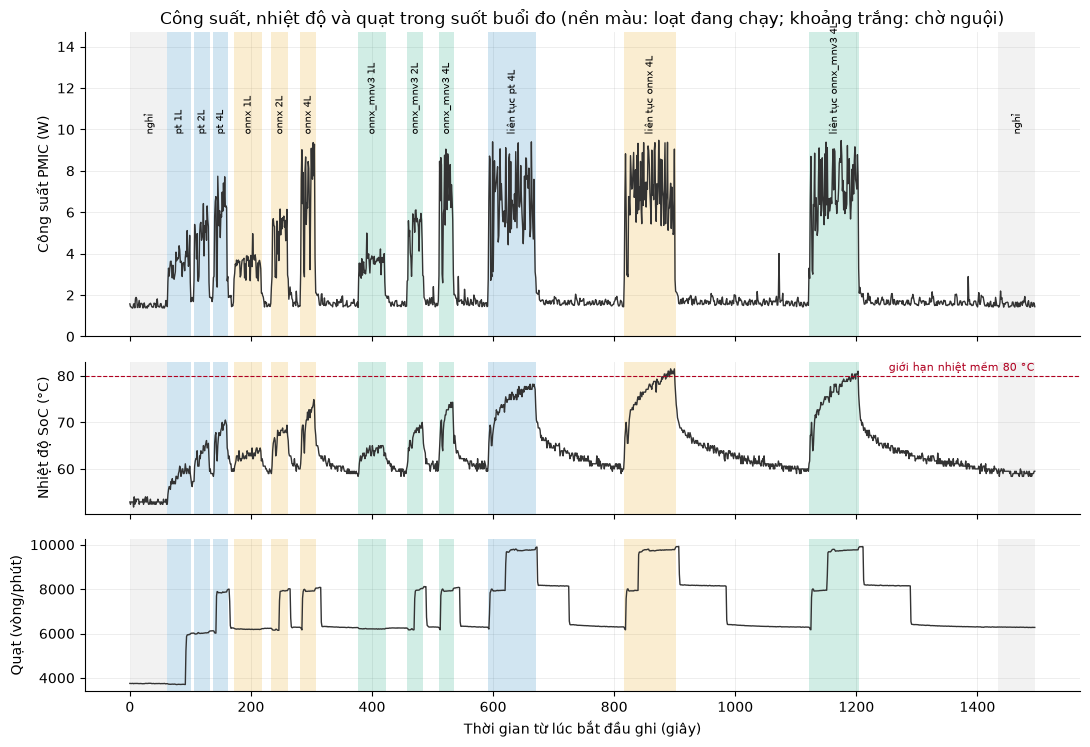

In [8]:
t0 = dien.t_unix.iloc[0]
dien["giay"] = dien.t_unix - t0
co_quat = "quat_rpm" in dien and dien.quat_rpm.notna().any()

n_hang = 3 if co_quat else 2
fig, axes = plt.subplots(n_hang, 1, figsize=(11, 2.2 * n_hang + 1), sharex=True,
                         gridspec_kw={"height_ratios": [2] + [1] * (n_hang - 1)})
axes[0].plot(dien.giay, dien.p_tong_w, color="#333333", lw=1)
axes[1].plot(dien.giay, dien.nhiet_do_c, color="#333333", lw=1)
axes[1].axhline(80, color="#B00020", lw=0.8, ls="--")
axes[1].text(dien.giay.iloc[-1], 80.5, "giới hạn nhiệt mềm 80 °C", ha="right", va="bottom", fontsize=8, color="#B00020")
if co_quat:
    axes[2].plot(dien.giay, dien.quat_rpm, color="#333333", lw=1)
    axes[2].set_ylabel("Quạt (vòng/phút)")

y_nhan = dien.p_tong_w.max() * 1.03
for _, m in moc.iterrows():
    a, b = m.t_bat_dau - t0, m.t_ket_thuc - t0
    mm = re.match(r"(bench|tai_lien_tuc)_(.+)_(\d)luong$", m.nhan)
    if mm is None:
        mau, nhan = "#BBBBBB", "nghỉ"
    else:
        mau = MAU[mm.group(2)]
        nhan = ("liên tục " if mm.group(1) == "tai_lien_tuc" else "") + f"{mm.group(2)} {mm.group(3)}L"
    for ax in axes:
        ax.axvspan(a, b, color=mau, alpha=0.18, lw=0)
    axes[0].text((a + b) / 2, y_nhan, nhan, ha="center", va="bottom", fontsize=7, rotation=90)

axes[0].set_ylabel("Công suất PMIC (W)")
axes[0].set_ylim(0, dien.p_tong_w.max() * 1.55)
axes[1].set_ylabel("Nhiệt độ SoC (°C)")
axes[-1].set_xlabel("Thời gian từ lúc bắt đầu ghi (giây)")
axes[0].set_title("Công suất, nhiệt độ và quạt trong suốt buổi đo (nền màu: loạt đang chạy; khoảng trắng: chờ nguội)")
fig.tight_layout()
fig.savefig(FIG_DIR / "pi5_dien_nang.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
p_nghi = float(np.median(pd.concat([
    dien[(dien.t_unix >= r.t_bat_dau) & (dien.t_unix <= r.t_ket_thuc)].p_tong_w
    for r in moc[moc.nhan.str.startswith("nghi_")].itertuples()
])))

bang_dien = lien_tuc[["cau_hinh", "trung_vi_ms", "p_trung_vi_w", "p_max_w", "cpu_trung_vi_pct",
                      "nhiet_do_max_c", "quat_rpm_max", "e_toan_phan_j", "e_tang_them_j"]].copy()
bang_dien.insert(3, "p_tang_them_w", bang_dien.p_trung_vi_w - p_nghi)
bang_dien["_thu_tu"] = bang_dien.cau_hinh.map(CAU_HINH.index)
bang_dien = bang_dien.sort_values("_thu_tu").drop(columns="_thu_tu")
bang_dien["cau_hinh"] = bang_dien.cau_hinh.map(TEN)
bang_dien.columns = ["Cấu hình (4 luồng, 60 lượt)", "t suy luận (ms)", "P tải (W)", "P tăng thêm (W)",
                     "P max (W)", "CPU (%)", "Nhiệt độ max (°C)", "Quạt max (vòng/phút)",
                     "E toàn phần (J/xe)", "E tăng thêm (J/xe)"]
display(Markdown(f"Đường nền lúc nghỉ: **{so_vn(p_nghi, 2)} W** "
                 f"(đầu buổi {so_vn(nghi.loc['nghi_truoc', 'p_trung_vi_w'], 2)} W, "
                 f"cuối buổi {so_vn(nghi.loc['nghi_sau', 'p_trung_vi_w'], 2)} W)"))
display(bang_dien.style.hide(axis="index").format(precision=2))

# Quy đổi cho dễ hình dung: 1 Wh = 3600 J
for r in lien_tuc.sort_values("cau_hinh", key=lambda s: s.map(CAU_HINH.index)).itertuples():
    display(Markdown(f"- {TEN[r.cau_hinh]}: 1 Wh xử lý được khoảng "
                     f"**{so_vn(3600 / r.e_toan_phan_j, 0)} lượt xe** (theo E toàn phần)."))

Đường nền lúc nghỉ: **1,54 W** (đầu buổi 1,46 W, cuối buổi 1,61 W)

"Cấu hình (4 luồng, 60 lượt)",t suy luận (ms),P tải (W),P tăng thêm (W),P max (W),CPU (%),Nhiệt độ max (°C),Quạt max (vòng/phút),E toàn phần (J/xe),E tăng thêm (J/xe)
"định vị .pt, kiểu dáng ResNet18",495.50,6.41,4.87,9.40,92.50,78.20,9871,3.18,2.41
"định vị .onnx, kiểu dáng ResNet18",547.50,6.82,5.28,9.47,98.30,81.50,9881,3.73,2.89
"định vị .onnx, kiểu dáng MobileNetV3-Small",544.30,6.71,5.17,9.46,98.30,81.00,9865,3.65,2.81


- định vị .pt, kiểu dáng ResNet18: 1 Wh xử lý được khoảng **1.134 lượt xe** (theo E toàn phần).

- định vị .onnx, kiểu dáng ResNet18: 1 Wh xử lý được khoảng **964 lượt xe** (theo E toàn phần).

- định vị .onnx, kiểu dáng MobileNetV3-Small: 1 Wh xử lý được khoảng **986 lượt xe** (theo E toàn phần).

Pi nghỉ tiêu khoảng 1,5 W (1,46 W đầu buổi, 1,61 W cuối buổi). Khi suy luận liên tục ở 4 luồng, công
suất khoảng 6,4 đến 6,8 W. Mỗi lượt xe tốn 3,2 J với cấu hình `pt`, 3,7 J với hai cấu hình `.onnx`,
chủ yếu vì thời gian mỗi lượt dài hơn. Quy đổi, 1 Wh xử lý được khoảng 970 đến 1.130 lượt xe.

Khi chạy liên tục, SoC lên 78 đến 81,5 °C và quạt quay gần 9.900 vòng/phút. Ở trạm cổng xe đến cách
nhau vài giây nên Pi nghỉ phần lớn thời gian, nhưng nếu xử lý video liên tục thì cần tản nhiệt tốt hơn.

Nhắc lại giới hạn ở mục 3: đây là công suất các nhánh do PMIC cấp, cận dưới của điện năng đo ở ổ điện.

## 9. Bộ nhớ

Đo riêng sau buổi đo chính bằng `src/ml/run_pi_ram.sh`, ở 4 luồng cho mỗi cấu hình: chạy
`benchmark_pipeline.py` (3 lượt) bên trong một tiến trình Python, cuối cùng in
`resource.getrusage(RUSAGE_SELF).ru_maxrss`. Đây là bộ nhớ thường trú lớn nhất tiến trình từng
dùng, đơn vị KiB trên Linux.

In [10]:
ram = []
for c_ in CAU_HINH:
    log = (PI5 / f"ram_{c_}_4luong.log").read_text(encoding="utf-8")
    kib = int(re.search(r"ru_maxrss_kb=(\d+)", log).group(1))
    dv = re.search(r"Định vị xe\s*:\s*(\S+)", log).group(1)
    kd = re.search(r"Kiểu dáng xe\s*:\s*(\S+)", log).group(1)
    ram.append((TEN[c_], dv, kd, kib / 1024, kib / 1024 / 1024))
display(pd.DataFrame(ram, columns=["Cấu hình", "Định vị (đầu log)", "Kiểu dáng (đầu log)", "Tối đa (MiB)", "Tối đa (GiB)"])
        .style.hide(axis="index").format({"Tối đa (MiB)": "{:.0f}", "Tối đa (GiB)": "{:.2f}"}))

Cấu hình,Định vị (đầu log),Kiểu dáng (đầu log),Tối đa (MiB),Tối đa (GiB)
"định vị .pt, kiểu dáng ResNet18",yolov8n.pt,vehicle-style-resnet18.onnx,766,0.75
"định vị .onnx, kiểu dáng ResNet18",yolov8n.onnx,vehicle-style-resnet18.onnx,742,0.72
"định vị .onnx, kiểu dáng MobileNetV3-Small",yolov8n.onnx,vehicle-style-mobilenet_v3_small.onnx,705,0.69


Tiến trình dùng tối đa khoảng 766 MiB (`pt`), 742 MiB (`onnx`) và 705 MiB (`onnx_mnv3`). Cột đầu log
xác nhận mỗi lần đo chạy đúng model. Script nạp pipeline hai lần trong cùng tiến trình nên đây là cận
trên cho một pipeline. Phần suy luận vừa với Pi 5 bản 4 GB. Chưa đo bộ nhớ khi backend và portal chạy
cùng lúc.

## 10. So với máy phát triển

Số máy phát triển (Intel Core i7-13700K, 24 luồng logic) lấy từ báo cáo trước, đo bằng cùng
script, cùng ảnh. Nguồn ghi ngay trong code.

In [11]:
# w7-onnx.md mục 2.1, bảng "Toàn pipeline (trung vị)", định vị .pt
MAY_DEV_PIPELINE_MS = {1: 146.8, 4: 76.2}
# w7-onnx.md mục 2.1, bảng từng model chạy riêng: (1 luồng, 4 luồng)
MAY_DEV_MODEL_MS = {
    "Phát hiện biển (YOLOv8n)": (65.58, 19.53),
    "OCR biển số (CRNN)": (1.14, 0.48),
    "Loại xe (ResNet18)": (24.57, 6.84),
    "Loại xe (MobileNetV3-Small)": (1.54, 0.90),
    "Kiểu dáng xe (ResNet18)": (25.21, 6.94),
}
# 05-phanloai.md mục 5.6: toàn pipeline 1 luồng, đo cùng lúc hai bản định vị xe
MAY_DEV_NHANH_MS = {"pt": 147.3, "onnx": 218.5}

pl = []
for l, dev in MAY_DEV_PIPELINE_MS.items():
    pi = bench[(bench.cau_hinh == "pt") & (bench.luong == l)].trung_vi_ms.iloc[0]
    pl.append((f"Toàn pipeline, {l} luồng (cấu hình pt)", dev, pi, pi / dev))
display(pd.DataFrame(pl, columns=["", "i7-13700K (ms)", "Pi 5 (ms)", "Pi chậm hơn"])
        .style.hide(axis="index").format({"i7-13700K (ms)": "{:.1f}", "Pi 5 (ms)": "{:.1f}", "Pi chậm hơn": "{:.1f}×"}))

mr1 = model_rieng[model_rieng.loat == "bench_pt_1luong"].set_index("model").trung_vi_ms
mr4 = model_rieng[model_rieng.loat == "bench_pt_4luong"].set_index("model").trung_vi_ms
bm = pd.DataFrame([(m, d1, mr1[m], mr1[m] / d1, d4, mr4[m], mr4[m] / d4) for m, (d1, d4) in MAY_DEV_MODEL_MS.items()],
                  columns=["Model", "i7, 1 luồng", "Pi, 1 luồng", "Pi chậm hơn (1)", "i7, 4 luồng", "Pi, 4 luồng", "Pi chậm hơn (4)"])
display(bm.style.hide(axis="index").format({"i7, 1 luồng": "{:.2f}", "Pi, 1 luồng": "{:.2f}", "i7, 4 luồng": "{:.2f}",
                                            "Pi, 4 luồng": "{:.2f}", "Pi chậm hơn (1)": "{:.1f}×", "Pi chậm hơn (4)": "{:.1f}×"}))

b1 = bench[bench.luong == 1].set_index("cau_hinh").trung_vi_ms
lech_dev = (MAY_DEV_NHANH_MS["onnx"] - MAY_DEV_NHANH_MS["pt"]) / MAY_DEV_NHANH_MS["pt"] * 100
lech_pi = (b1["onnx"] - b1["pt"]) / b1["pt"] * 100
display(Markdown(f"Toàn pipeline khi đổi bước định vị xe từ `.pt` sang `.onnx`, 1 luồng: chậm hơn **{so_vn(lech_dev)}%** "
                 f"trên i7-13700K, **{'chậm hơn' if lech_pi > 0 else 'nhanh hơn'} {so_vn(abs(lech_pi))}%** trên Pi 5."))

,i7-13700K (ms),Pi 5 (ms),Pi chậm hơn
"Toàn pipeline, 1 luồng (cấu hình pt)",146.8,813.9,5.5×
"Toàn pipeline, 4 luồng (cấu hình pt)",76.2,495.3,6.5×


Model,"i7, 1 luồng","Pi, 1 luồng",Pi chậm hơn (1),"i7, 4 luồng","Pi, 4 luồng",Pi chậm hơn (4)
Phát hiện biển (YOLOv8n),65.58,361.10,5.5×,19.53,141.85,7.3×
OCR biển số (CRNN),1.14,6.07,5.3×,0.48,2.30,4.8×
Loại xe (ResNet18),24.57,129.47,5.3×,6.84,44.99,6.6×
Loại xe (MobileNetV3-Small),1.54,12.66,8.2×,0.90,5.75,6.4×
Kiểu dáng xe (ResNet18),25.21,129.42,5.1×,6.94,45.53,6.6×


Toàn pipeline khi đổi bước định vị xe từ `.pt` sang `.onnx`, 1 luồng: chậm hơn **48,3%** trên i7-13700K, **chậm hơn 31,1%** trên Pi 5.

Toàn pipeline trên Pi chậm hơn máy phát triển khoảng 5,5 lần ở 1 luồng và 6,5 lần ở 4 luồng. Bản
`.onnx` của bước định vị xe chậm hơn bản `.pt` trên cả hai máy: 48% trên x86 và 31% trên Pi (1 luồng).

## 11. Tổng kết

- **Đạt mốc đề cương.** Pipeline chạy 495,3 ms mỗi lượt trên Raspberry Pi 5 (định vị `.pt`, 4 luồng),
  nhanh hơn mốc 2 giây khoảng 4 lần. Đo độc lập 5 lần lệch nhau không quá 1,04%.
- **Cấu hình nên dùng trên Pi.** Định vị xe bằng `.pt`, kiểu dáng bằng MobileNetV3-Small ONNX,
  `ML_INTRAOP_THREADS=4`. MobileNetV3-Small đã đặt làm mặc định trong code: accuracy ngang ResNet18,
  bản ONNX khớp `.pt` 987/987 ảnh, bớt khoảng 48 ms mỗi lượt ô tô ở 4 luồng.
- **Điện năng.** Khoảng 3,2 J mỗi lượt xe với cấu hình `pt`, nghỉ khoảng 1,5 W. Đây là cận dưới của
  điện năng ở ổ điện.
- **Tính hợp lệ.** Lần chạy chính đạt 5/9 kiểm tra; bốn mục không đạt đều liên quan nhiệt độ và dao
  động, không có mẫu nào bị hạ xung. Lần đo trước phát hiện và sửa một lỗi của chính script đo
  (biến môi trường không được đọc), nay mọi log ghi tên model thật sự chạy.

Hạn chế: chưa có đồng hồ đo ở ổ điện; ảnh đo là xe máy có 12 biển, không đại diện ảnh ô tô ở camera
cổng; chưa đo cấu hình `.pt` + MobileNetV3-Small trọn pipeline (suy từ hai phép đo từng bước); chưa đo
khi backend, portal và camera chạy cùng lúc; chưa thử lượng tử hoá INT8.